In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
import matplotlib.animation as animation

from scipy.optimize import curve_fit
import scipy.ndimage as ndimage
from scipy.stats import multivariate_normal
from scipy.ndimage import gaussian_filter
from scipy import signal
from scipy.stats import norm 
import scipy.stats as stats
import scipy.optimize as opt

from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F

from mpl_toolkits.mplot3d import Axes3D

from sklearn import mixture
from sklearn.mixture import GaussianMixture

import os, sys, fnmatch
from os.path import isfile, join

## Elliptical Gaussian Fitting

C:\Users\hankeun2\Desktop\brian_test\images\images\image1\square_001.tif


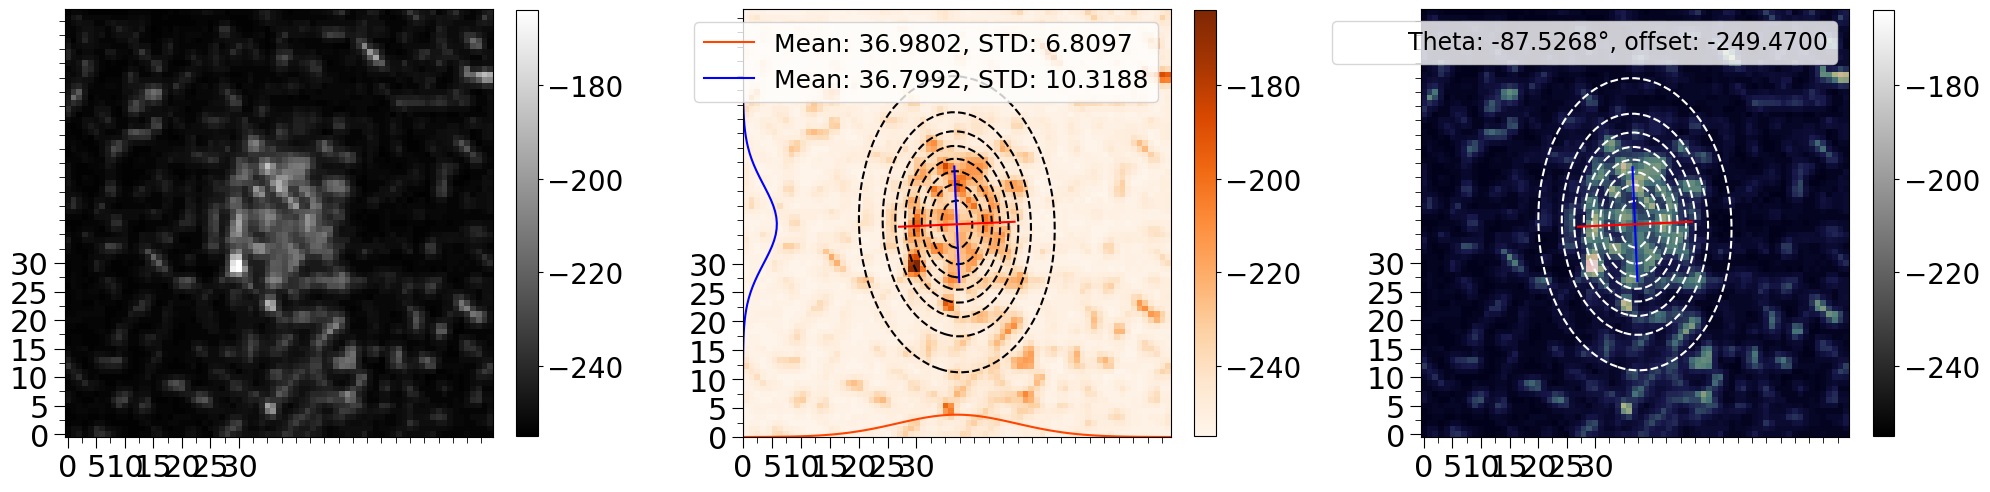

C:\Users\hankeun2\Desktop\brian_test\images\images\image1\square_002.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image1\square_003.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image1\square_004.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image1\square_005.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image1\square_006.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image1\square_007.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image1\square_008.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image1\square_009.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image1\square_010.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image1\square_011.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image1\square_012.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image1\square_013.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image1\square_014.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\

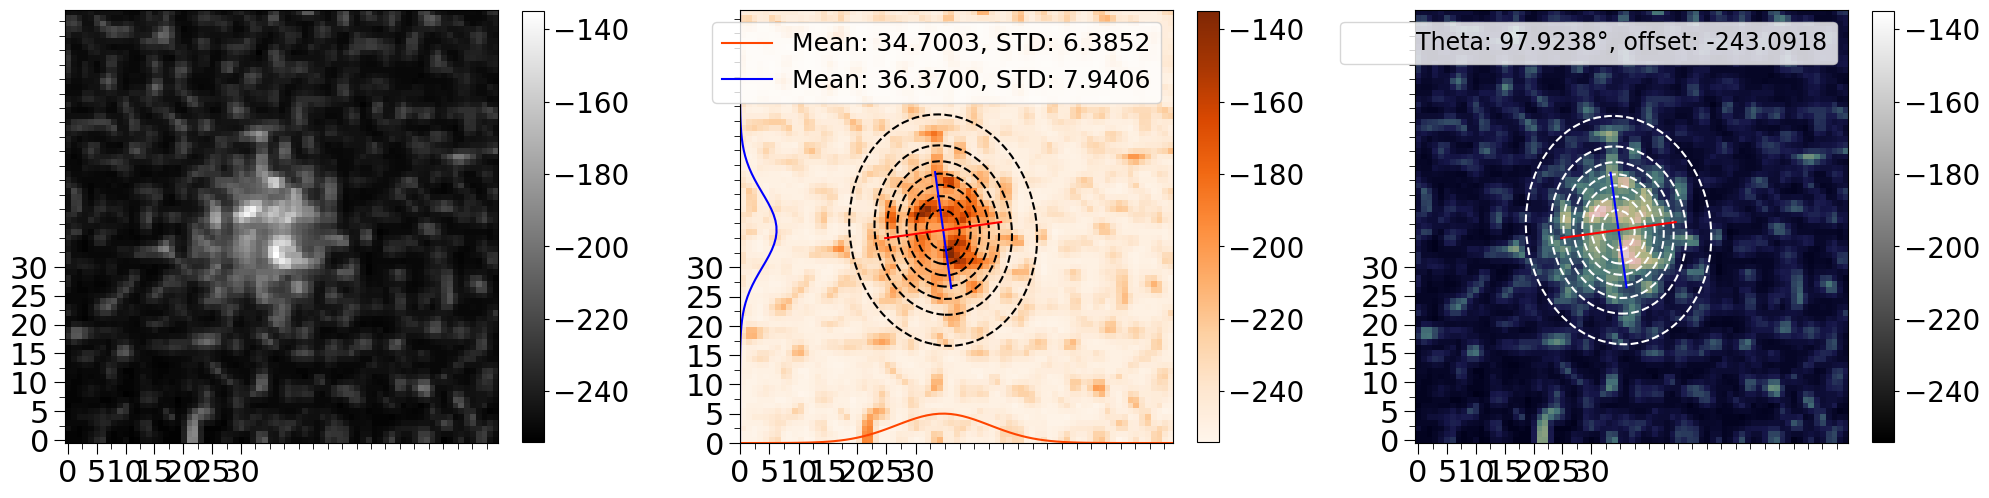

C:\Users\hankeun2\Desktop\brian_test\images\images\image2\square_002.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image2\square_003.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image2\square_004.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image2\square_005.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image2\square_006.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image2\square_007.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image2\square_008.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image2\square_009.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image2\square_010.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image2\square_011.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image2\square_012.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image2\square_013.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image2\square_014.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\

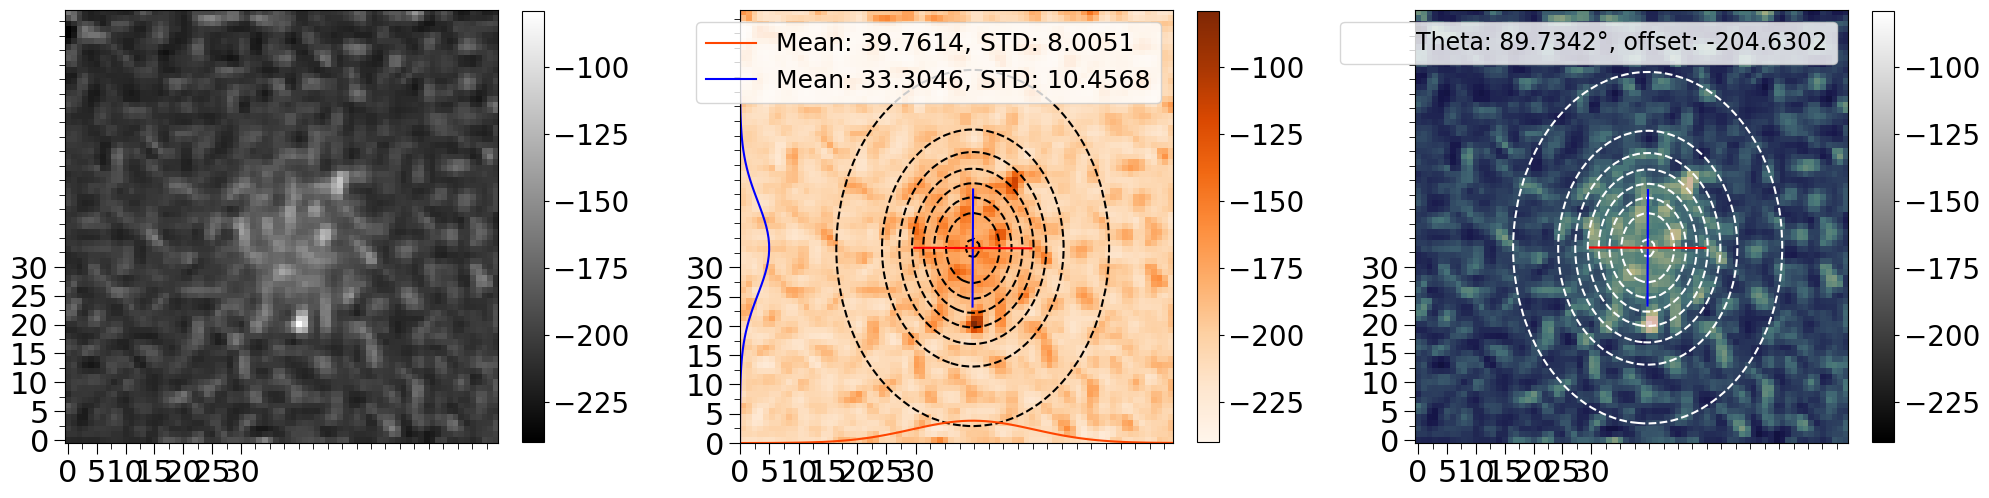

C:\Users\hankeun2\Desktop\brian_test\images\images\image3\square_002.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image3\square_003.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image3\square_004.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image3\square_005.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image3\square_006.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image3\square_007.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image3\square_008.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image3\square_009.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image3\square_010.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image3\square_011.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image3\square_012.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image3\square_013.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image3\square_014.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\

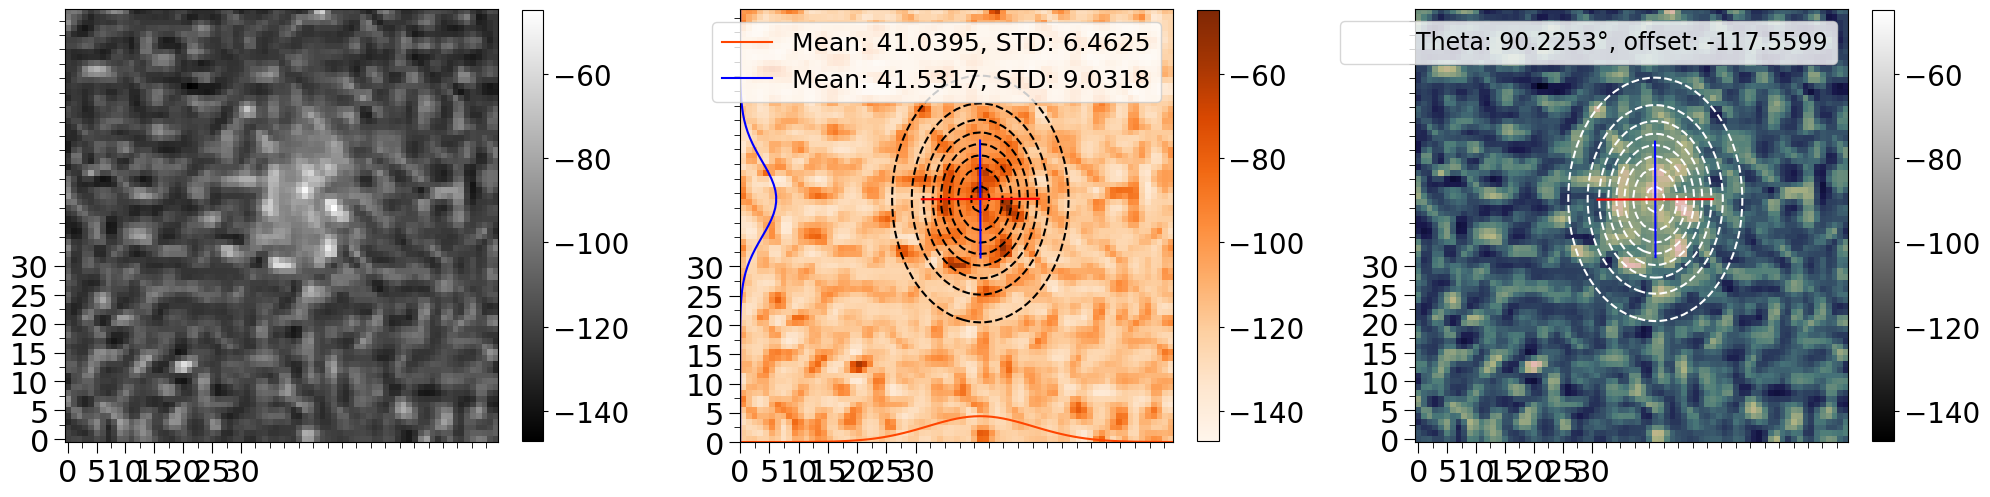

C:\Users\hankeun2\Desktop\brian_test\images\images\image4\square_002.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image4\square_003.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image4\square_004.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image4\square_005.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image4\square_006.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image4\square_007.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image4\square_008.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image4\square_009.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image4\square_010.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image4\square_011.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image4\square_012.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image4\square_013.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image4\square_014.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\

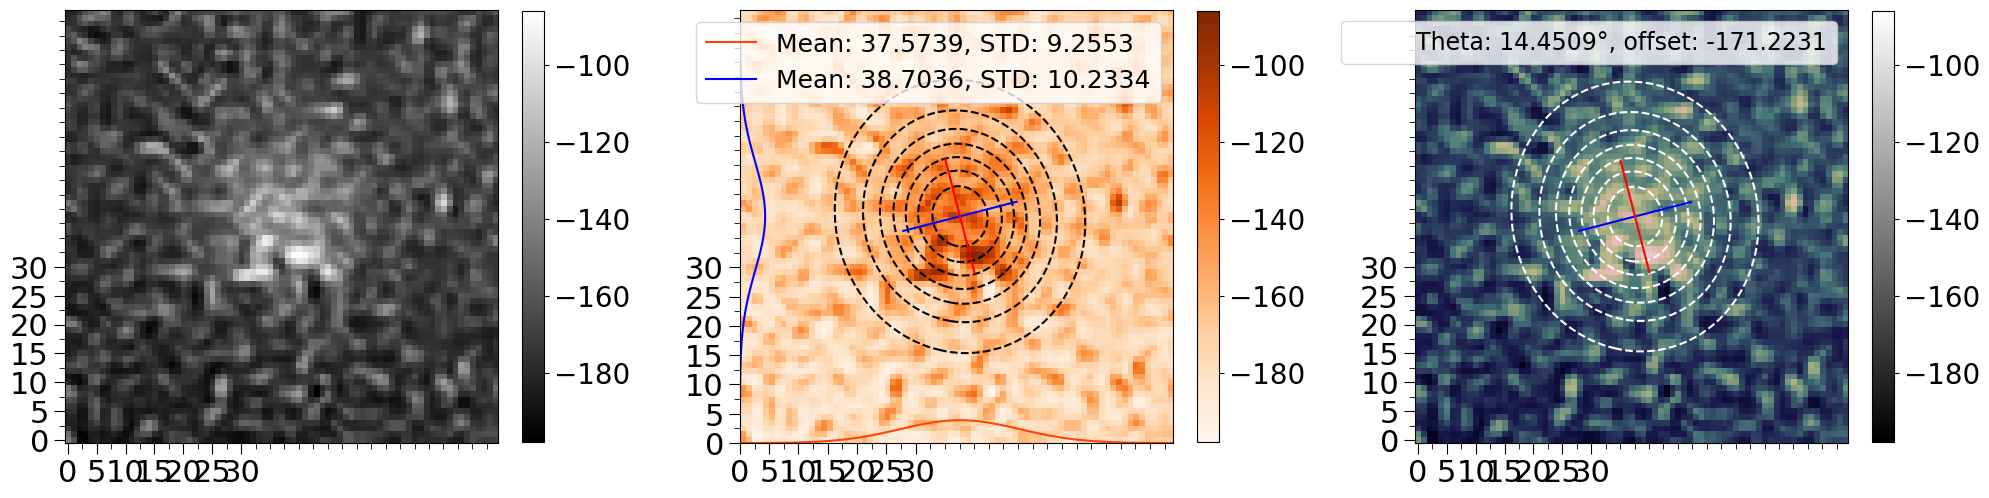

C:\Users\hankeun2\Desktop\brian_test\images\images\image5\square_002.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image5\square_003.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image5\square_004.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image5\square_005.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image5\square_006.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image5\square_007.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image5\square_008.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image5\square_009.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image5\square_010.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image5\square_011.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image5\square_012.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image5\square_013.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image5\square_014.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\

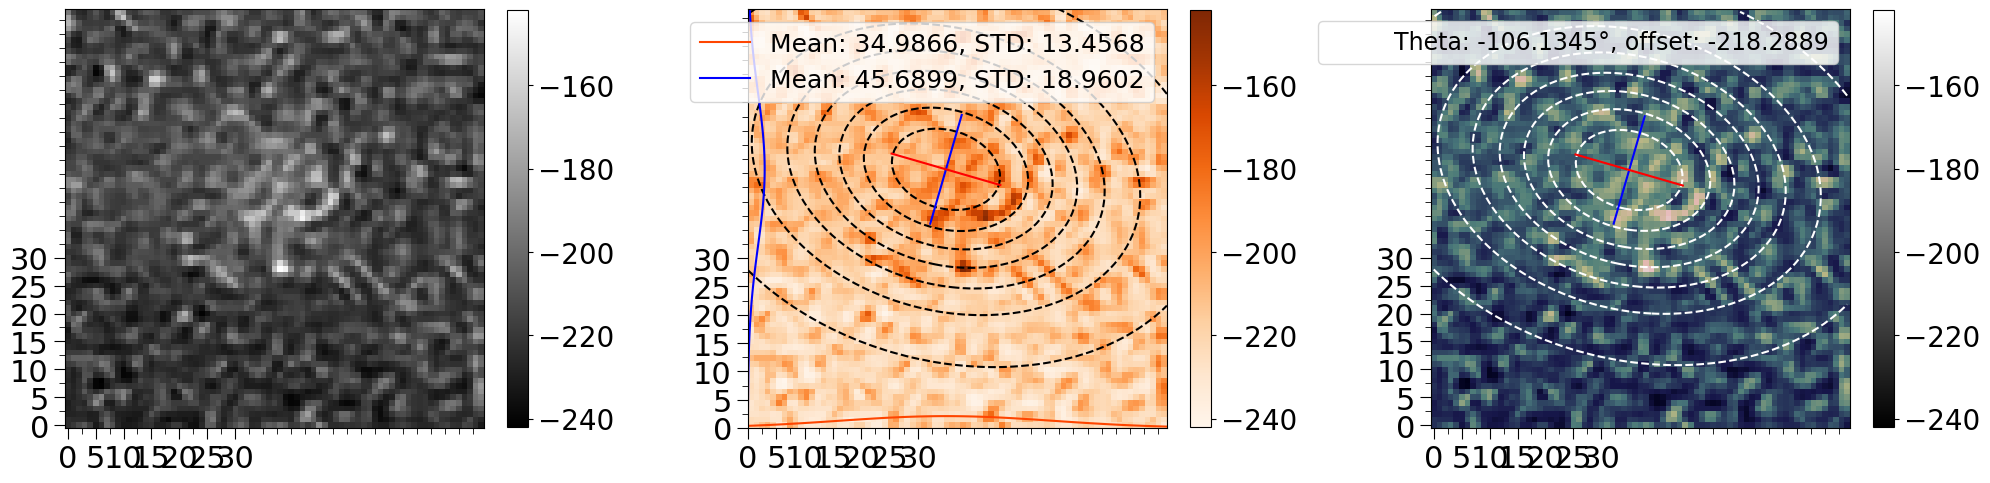

C:\Users\hankeun2\Desktop\brian_test\images\images\image6\square_002.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image6\square_003.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image6\square_004.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image6\square_005.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image6\square_006.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image6\square_007.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image6\square_008.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image6\square_009.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image6\square_010.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image6\square_011.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image6\square_012.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image6\square_013.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image6\square_014.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\

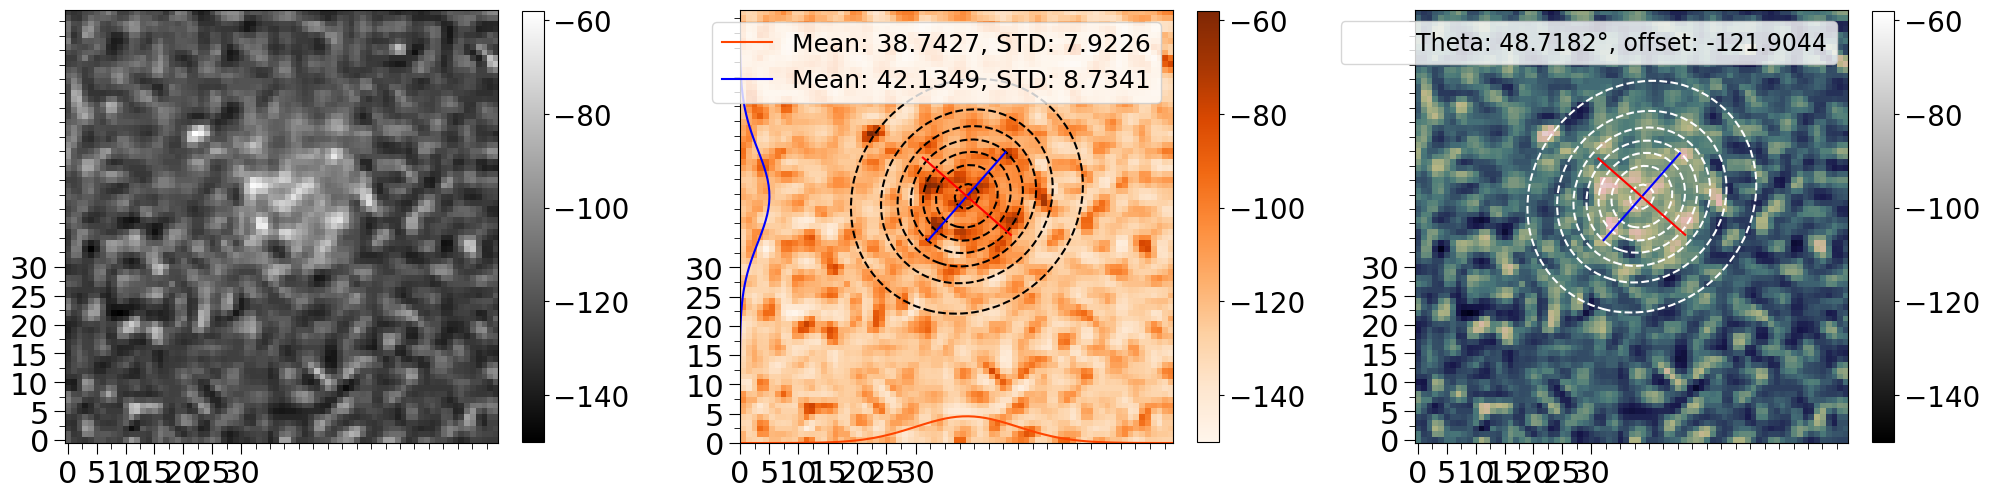

C:\Users\hankeun2\Desktop\brian_test\images\images\image7\square_002.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image7\square_003.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image7\square_004.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image7\square_005.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image7\square_006.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image7\square_007.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image7\square_008.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image7\square_009.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image7\square_010.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image7\square_011.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image7\square_012.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image7\square_013.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image7\square_014.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\

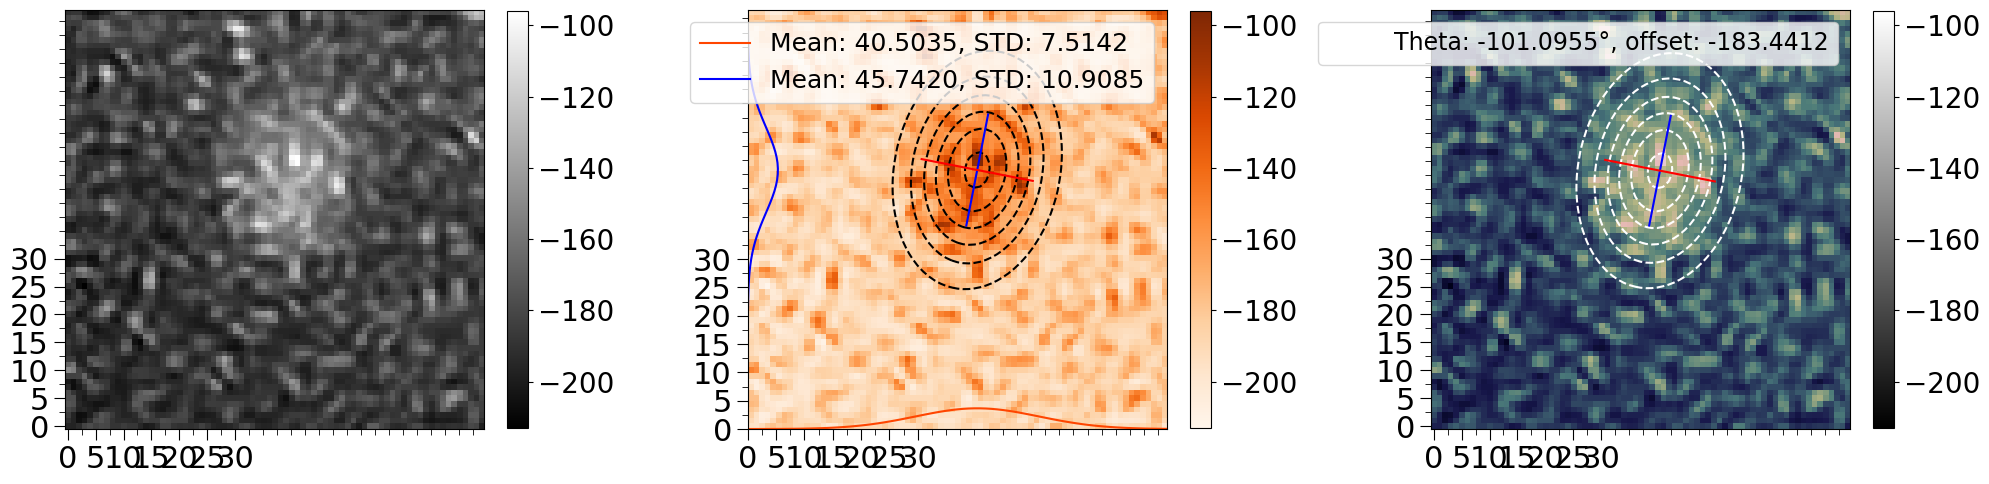

C:\Users\hankeun2\Desktop\brian_test\images\images\image8\square_002.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image8\square_003.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image8\square_004.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image8\square_005.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image8\square_006.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image8\square_007.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image8\square_008.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image8\square_009.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image8\square_010.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image8\square_011.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image8\square_012.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image8\square_013.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\image8\square_014.tif
C:\Users\hankeun2\Desktop\brian_test\images\images\

In [2]:
def twoD_Gaussian(xy, amplitude, xo, yo, sigma_x, sigma_y, theta, offset):
    x, y = xy
    xo = float(xo)
    yo = float(yo)    
    a = (np.cos(theta)**2/(2*sigma_x**2)) + (np.sin(theta)**2/(2*sigma_y**2))
    b = -(np.sin(2*theta)/(4*sigma_x**2)) + (np.sin(2*theta)/(4*sigma_y**2))
    c = (np.sin(theta)**2/(2*sigma_x**2)) + (np.cos(theta)**2/(2*sigma_y**2))
    g = offset + amplitude * np.exp(-(a*((x-xo)**2) + 2*b*(x-xo)*(y-yo) + c*((y-yo)**2)))
    return g.ravel()

def find_images(pattern, path):
    result = []
    for root, dirs, files in os.walk(path):
        for name in files:
            if fnmatch.fnmatch(name, pattern):
                result.append(os.path.join(root, name))
    return result

def find_all_psf_images(base_path):
    """Find all images in img1, img2, ..., img7 folders ONLY"""
    result = []
    for i in range(1, 9):  # img1 through img7
        folder = os.path.join(base_path, f'image{i}')
        # Check if it exists AND is exactly img1, img2, etc (not img1-copy)
        if os.path.exists(folder) and os.path.isdir(folder):
            for file in os.listdir(folder):
                filepath = os.path.join(folder, file)
                if os.path.isfile(filepath) and file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                    result.append(filepath)
    return sorted(result)

# Use it:
psf_images_dir = find_all_psf_images(os.path.join(os.getcwd(), 'images', 'images'))

mus = []
stds = []
stds_ratio = []
thetas = []
offsets = []
amplitudes = []
rmse_list = [] 

for i, psf_dir in enumerate(psf_images_dir): 
    print(psf_dir)
    # Load image directly; use red channel if it's RGB. Convert to float32
    # BEFORE negation so the negation is a true sign flip (not uint8 wrap-
    # around). This keeps amplitudes in red-channel units, which is what
    # the training synthesis uses.
    raw = np.asarray(Image.open(psf_dir))
    if raw.ndim == 3:
        raw = raw[:, :, 0]   # red channel of RGB TIFs
    psf_image = -raw.astype(np.float32)
    img_width, img_height = psf_image.shape

    # Create x and y indices
    x_axis = np.linspace(0, img_width - 1, img_width)
    y_axis = np.linspace(0, img_height - 1 , img_height)
    x, y = np.meshgrid(x_axis, y_axis, indexing='xy')
    
    data_noisy = psf_image.ravel()

    # DYNAMIC initial guess based on actual image size
    # Robust initial guess based on the image statistics:
    # offset ~ median (bg level), amplitude ~ how high the peak is above bg.
    init_offset = float(np.median(psf_image))
    init_amplitude = float(np.percentile(psf_image, 99) - init_offset)
    if init_amplitude < 1.0:
        init_amplitude = 30.0   # fallback for flat crops
    initial_guess = (init_amplitude, img_width/2, img_height/2,
                     img_width/10, img_height/10, np.pi/2, init_offset)
    popt, pcov = opt.curve_fit(twoD_Gaussian, (x, y), data_noisy, p0=initial_guess)

    data_fitted = twoD_Gaussian((x, y), *popt)
    
    mu = [popt[1], popt[2]]
    std = [abs(popt[3]), abs(popt[4])]

    # Calculate RMSE for the fitted Gaussian
    rmse = np.sqrt(np.mean((data_noisy - data_fitted) ** 2))
    rmse_list.append(rmse)

    if std[0] < std[1]:
        temp = std[0]
        std[0] = std[1]
        std[1] = temp

    theta_radians = (-1) * popt[5]  # Correct the rotation for the image coordinate system
    theta_degrees = np.degrees(theta_radians) # Convert radians to degrees
    theta_degrees = ((theta_degrees + 180) % 360) - 180 # Normalize the angle to be within the range of -180 to 180 degrees
    theta_radians = np.radians(theta_degrees)

    mus.append(mu)
    stds.append(std)
    stds_ratio.append(std[0]/std[1])
    thetas.append(theta_degrees)
    offsets.append(popt[6])
    amplitudes.append(popt[0])
    
    # ONLY visualize every 20th image
    if i % 20 == 0:
        x_prime_endpoint_pos = (mu[0] + 10 * np.cos(theta_radians), mu[1] + 10 * np.sin(theta_radians))
        x_prime_endpoint_neg = (mu[0] - 10 * np.cos(theta_radians), mu[1] - 10 * np.sin(theta_radians))
        y_prime_endpoint_pos = (mu[0] - 10 * np.sin(theta_radians), mu[1] + 10 * np.cos(theta_radians))
        y_prime_endpoint_neg = (mu[0] + 10 * np.sin(theta_radians), mu[1] - 10 * np.cos(theta_radians))
        
        fig, axs = plt.subplots(1,3, figsize=(20, 7))
        for j, ax in enumerate(axs.flatten()):  # Changed 'i' to 'j' to avoid variable conflict
            ax.tick_params(axis='both', which='major', labelsize=22, length=8)  # Major ticks
            ax.tick_params(axis='both', which='minor', labelsize=20, length=4)  # Minor ticks
            ax.set_xticks([0, 5, 10, 15, 20, 25, 30])  # Adjust this to your specific density values
            ax.set_yticks([0, 5, 10, 15, 20, 25, 30])
            ax.xaxis.set_minor_locator(AutoMinorLocator(2))  # 2 minor ticks between each major tick
            ax.yaxis.set_minor_locator(AutoMinorLocator(2))  # 2 minor ticks between each major tick
            asp = np.diff(ax.get_xlim())[0] / np.diff(ax.get_ylim())[0]
            ax.set_aspect(asp) # To set the aspect ratio the same for all images
            
            if j == 0:
                a = ax.imshow(psf_image, cmap='gray', origin='lower')
            if j == 1:
                a = ax.imshow(psf_image, cmap='Oranges', origin='lower', extent=(x.min(), x.max(), y.min(), y.max()))
                ax.contour(x, y, data_fitted.reshape(img_height, img_width), 7, colors='black')
                ax.plot(x_axis, 100 * norm.pdf(x_axis, mu[0], std[0]), c='orangered', label=f"Mean: {mu[0]:.4f}, STD: {std[1]:.4f}")
                ax.plot(100 * norm.pdf(x_axis, mu[1], std[1]), y_axis, c='blue', label=f"Mean: {mu[1]:.4f}, STD: {std[0]:.4f}")
                ax.plot([x_prime_endpoint_neg[0], x_prime_endpoint_pos[0]], [x_prime_endpoint_neg[1], x_prime_endpoint_pos[1]], 'b-')
                ax.plot([y_prime_endpoint_neg[0], y_prime_endpoint_pos[0]], [y_prime_endpoint_neg[1], y_prime_endpoint_pos[1]], 'r-')
                ax.legend(loc="upper right", fontsize=18)
            if j == 2:
                a = ax.imshow(psf_image, cmap='gray', origin='lower')
                ax.imshow(psf_image, alpha=0.2, cmap="jet", origin='lower')
                ax.contour(x, y, data_fitted.reshape(img_height, img_width), 7, colors='white')
                ax.plot([x_prime_endpoint_neg[0], x_prime_endpoint_pos[0]], [x_prime_endpoint_neg[1], x_prime_endpoint_pos[1]], 'b-')
                ax.plot([y_prime_endpoint_neg[0], y_prime_endpoint_pos[0]], [y_prime_endpoint_neg[1], y_prime_endpoint_pos[1]], 'r-')
                ax.plot([], [], ' ', label=f"Theta: {theta_degrees:.4f}°, offset: {popt[6]:.4f}")
                # ax.set_title(f'Gaussian Fitting\n(Angle of Rotation and Offset)', fontsize=20)
                ax.legend(loc="upper right", fontsize=17)
            
            # Add a colorbar with custom font size
            cbar = fig.colorbar(a, ax=ax, fraction=0.045)
            cbar.ax.tick_params(labelsize=20)  # Set font size for colorbar ticks
            # cbar.set_label('Colorbar Label', fontsize=20)  # Set font size for the colorbar label
        
        plt.tight_layout()
        plt.show()

stds = np.asarray(stds).transpose((1,0)) # Shape: (2, N) -> Row 0 is SigX, Row 1 is SigY
thetas = np.asarray(thetas)
offsets = np.asarray(offsets)
amplitudes = np.asarray(amplitudes)
rmse_arr = np.asarray(rmse_list)

# =============================================================================
# NEW: AUTOMATIC OUTLIER REMOVAL (IQR Method)
# =============================================================================
# We filter based on Sigma X because that was the main source of high variance.
# You can also apply this to Sigma Y if needed.

# 1. Calculate Statistics for Sigma X
sig_x = stds[0, :]
Q1 = np.percentile(sig_x, 25)
Q3 = np.percentile(sig_x, 75)
IQR = Q3 - Q1

# 2. Define "Normal" Range (1.5 * IQR is standard for removing outliers)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Create a "Keep" Mask
# We keep data where Sigma X is within bounds AND Sigma Y is reasonable (e.g., < 150)
mask = (sig_x >= lower_bound) & (sig_x <= upper_bound) & (stds[1, :] < 150)

# Optional: Filter out bad fits with extremely high RMSE (e.g., fitting noise)
# mask = mask & (rmse_arr < np.percentile(rmse_arr, 95)) 

# 4. Apply Mask to ALL data arrays
stds_clean = stds[:, mask]
offsets_clean = offsets[mask]
amplitudes_clean = amplitudes[mask]
rmse_clean = rmse_arr[mask]

print(f"\n--- OUTLIER REMOVAL REPORT ---")
print(f"Original Count: {len(sig_x)}")
print(f"Outliers Removed: {np.sum(~mask)} (Indices: {np.where(~mask)[0]})")
print(f"Clean Count: {len(offsets_clean)}")
print(f"Sigma X Thresholds: {lower_bound:.2f} to {upper_bound:.2f}")
print("------------------------------\n")

# =============================================================================
# UPDATED PRINTOUTS (Using Cleaned Data)
# =============================================================================

print(f"Mean of Standard Deviation X-Axis: {np.mean(stds_clean[0,:])}, STD of STD X-Axis: {np.std(stds_clean[0,:])}")
print(f"Mean of Standard Deviation Y-Axis: {np.mean(stds_clean[1,:])}, STD of STD X-Axis: {np.std(stds_clean[1,:])}" )
print(f"Mean of offsets: {np.mean(offsets_clean)}, STD of offsets: {np.std(offsets_clean)}" )
print(f"Mean of Amplitude: {np.mean(amplitudes_clean)}, STD of amplitudes: {np.std(amplitudes_clean)}")
print(f"Mean RMSE: {np.mean(rmse_clean)}, STD of RMSE: {np.std(rmse_clean)}")

# Note: Update your generator with THESE new values!



PSF FIT QUALITY EVALUATION

Sample Image Intensity:
  Min: -255.00
  Max: -164.00
  Range: 91.00

RMSE Analysis:
  Mean RMSE: 10.9440
  Std RMSE: 1.0350
  RMSE as % of intensity range: 12.03%
  Min RMSE: 7.2027
  Max RMSE: 13.6717


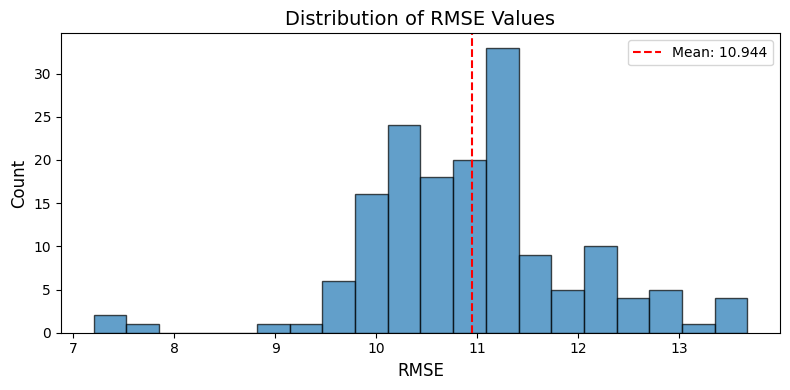

In [3]:
# Quick RMSE Evaluation
print("\n" + "="*60)
print("PSF FIT QUALITY EVALUATION")
print("="*60)

# 1. Check intensity range from a sample image (same load logic as cell 2)
raw_sample = np.asarray(Image.open(psf_images_dir[0]))
if raw_sample.ndim == 3:
    raw_sample = raw_sample[:, :, 0]
sample_image = -raw_sample.astype(np.float32)
intensity_range = sample_image.max() - sample_image.min()

print(f"\nSample Image Intensity:")
print(f"  Min: {sample_image.min():.2f}")
print(f"  Max: {sample_image.max():.2f}")
print(f"  Range: {intensity_range:.2f}")

# 2. RMSE as percentage of intensity range
rmse_array = np.array(rmse_list)
rmse_percentage = (np.mean(rmse_array) / intensity_range) * 100

print(f"\nRMSE Analysis:")
print(f"  Mean RMSE: {np.mean(rmse_array):.4f}")
print(f"  Std RMSE: {np.std(rmse_array):.4f}")
print(f"  RMSE as % of intensity range: {rmse_percentage:.2f}%")
print(f"  Min RMSE: {np.min(rmse_array):.4f}")
print(f"  Max RMSE: {np.max(rmse_array):.4f}")

# 3. Interpretation
#print(f"\nInterpretation:")
#if rmse_percentage < 2:
#    print("  ✓ EXCELLENT fit quality (<2% error)")
#elif rmse_percentage < 5:
#    print("  ✓ GOOD fit quality (2-5% error)")
#elif rmse_percentage < 10:
#    print("  ⚠ ACCEPTABLE fit quality (5-10% error)")
#else:
#    print("  ✗ POOR fit quality (>10% error)")

#print(f"\n  Consistency: ", end="")
#if np.std(rmse_array) < np.mean(rmse_array) * 0.2:
#    print("✓ High (low variation in fits)")
#else:
#    print("⚠ Moderate (some variation in fit quality)")

# 4. Quick histogram
plt.figure(figsize=(8, 4))
plt.hist(rmse_array, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(np.mean(rmse_array), color='red', linestyle='--', label=f'Mean: {np.mean(rmse_array):.3f}')
plt.xlabel('RMSE', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of RMSE Values', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

print("="*60)

## 3D graph of sigma_x, sigma_y, and amplitude 
### ellipsoid drawing with its center at each axis mean

In [4]:
print("\nData Ranges:")
print(f"stds[0] (sigma_x): min={stds[0].min():.2f}, max={stds[0].max():.2f}, mean={stds[0].mean():.2f}")
print(f"stds[1] (sigma_y): min={stds[1].min():.2f}, max={stds[1].max():.2f}, mean={stds[1].mean():.2f}")
print(f"amplitudes: min={amplitudes.min():.2f}, max={amplitudes.max():.2f}, mean={amplitudes.mean():.2f}")
print(f"\nraw_data_points shape: {raw_data_points.shape}")


Data Ranges:
stds[0] (sigma_x): min=7.48, max=37.27, mean=10.49
stds[1] (sigma_y): min=4.41, max=26.34, mean=8.33
amplitudes: min=12.37, max=69.60, mean=30.62


NameError: name 'raw_data_points' is not defined

In [5]:
plt.close('all')
from matplotlib import cm
import matplotlib.cm as cmx
import pandas as pd
import openpyxl

raw_data_points = np.array([stds[0], stds[1], amplitudes]).T
print(raw_data_points.shape)

means = np.array([[stds[0].mean(), stds[1].mean(), amplitudes.mean()]])
# Constructing the data points for covariance calculation
data_points = np.vstack((stds[0], stds[1], amplitudes)).T  # Shape should be (n_samples, n_features)

# Calculate the covariance matrix
cov_matrix = np.cov(data_points, rowvar=False)  # Set rowvar=False to treat columns as variables
covs = np.array([cov_matrix])
print(covs)

n_gaussians = means.shape[0]  #Number of clusters

N = 1000 # Number of points to be generated for each cluster.
points = []
for i in range(len(means)):
    x = np.random.multivariate_normal(means[i], covs[i], N )
    points.append(x)
points = np.concatenate(points)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:,0], points[:,1], points[:,2], s=1, alpha=1)
ax.view_init(35.246, 45)
# DYNAMIC LIMITS
ax.set_xlim([points[:,0].min()*0.9, points[:,0].max()*1.1])
ax.set_ylim([points[:,1].min()*0.9, points[:,1].max()*1.1])
ax.set_zlim([points[:,2].min()*0.9, points[:,2].max()*1.1])
plt.show()

#fit the gaussian model
gmm = GaussianMixture(n_components=n_gaussians, covariance_type='diag')
gmm.fit(points)

def plot_sphere(w=0, c=[0,0,0], r=[1, 1, 1], subdev=20, ax=None, sigma_multiplier=3):
    '''
        plot a sphere surface
        Input: 
            c: 3 elements list, sphere center
            r: 3 element list, sphere original scale in each axis ( allowing to draw elipsoids)
            subdiv: scalar, number of subdivisions (subdivision^2 points sampled on the surface)
            ax: optional pyplot axis object to plot the sphere in.
            sigma_multiplier: sphere additional scale (choosing an std value when plotting gaussians)
        Output:
            ax: pyplot axis object
    '''

    if ax is None:
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
    pi = np.pi
    cos = np.cos
    sin = np.sin
    phi, theta = np.mgrid[0.0:pi:complex(0,subdev), 0.0:2.0 * pi:complex(0,subdev)]
    x = sigma_multiplier*r[0] * sin(phi) * cos(theta) + c[0]
    y = sigma_multiplier*r[1] * sin(phi) * sin(theta) + c[1]
    z = sigma_multiplier*r[2] * cos(phi) + c[2]
    cmap = cmx.ScalarMappable()
    cmap.set_cmap('jet')
    c = cmap.to_rgba(w)

    ax.plot_surface(x, y, z, color=c, alpha=0.2, linewidth=1)

    return ax

def plot_ellipsoid(c, cov, ax=None, color='blue', alpha=0.9, radius_multiplier=2.5, subdev=10):
    ax = ax or plt.gca()
    
    # Calculate the eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(cov)

    # Create a grid of points on a unit sphere
    phi = np.linspace(0, np.pi, subdev)  # Increase density for smoother surface
    theta = np.linspace(0, 2 * np.pi, subdev)
    # Create meshgrid for spherical coordinates
    phi, theta = np.meshgrid(phi, theta)
    # Parametrize the surface of the ellipsoid
    x = radius_multiplier * np.sqrt(eigenvalues[0]) * np.outer(np.sin(phi), np.cos(theta))
    y = radius_multiplier * np.sqrt(eigenvalues[1]) * np.outer(np.sin(phi), np.sin(theta))
    z = radius_multiplier * np.sqrt(eigenvalues[2]) * np.outer(np.cos(phi), np.ones_like(theta))
    # Rotate the ellipsoid using the eigenvectors

    ellipsoid_points = np.dot(eigenvectors, np.array([x.flatten(), y.flatten(), z.flatten()]))
    x = ellipsoid_points[0].reshape(x.shape) + c[0]
    y = ellipsoid_points[1].reshape(y.shape) + c[1]
    z = ellipsoid_points[2].reshape(z.shape) + c[2]
    
    # Calculate the radial distance from the center
    distances = np.sqrt((x - c[0])**2 + (y - c[1])**2 + (z - c[2])**2)
    
    # Normalize distances to range [0, 1]
    normalized_distances = (distances - distances.min()) / (distances.max() - distances.min()) - 0.2

    # Create a color map based on normalized distances
    my_col = cm.plasma(normalized_distances)  # You can choose a different colormap

    # Plot the surface of the ellipsoid
    ax.plot_surface(x, y, z, facecolors=my_col, alpha=alpha, linewidth=0, antialiased=True, shade=True)

def visualize_3d_gmm(points, w, mu, stdev):
    '''
    plots points and their corresponding gmm model in 3D
    Input: 
        points: N X 3, sampled points
        w: n_gaussians, gmm weights
        mu: 3 X n_gaussians, gmm means
        stdev: 3 X n_gaussians, gmm standard deviation (assuming diagonal covariance matrix)
    Output:
        None
    '''

    n_gaussians = mu.shape[1]
    N = int(np.round(points.shape[0] / n_gaussians))
    N = raw_data_points.shape[0]
    # Visualize data
    
    # Create a 2x2 subplot structure
    fig = plt.figure(figsize=(10, 10))
    # Top-left: 3D projection
    ax_3d = fig.add_subplot(111, projection='3d')
    ax_3d.set_facecolor('none')
    
    colors = cmx.Set1(np.linspace(0, 1, n_gaussians))
    # Set the background color to transparent
    for i in range(n_gaussians):
        idx = range(i * N, (i + 1) * N)
        # axes.scatter(points[idx, 0], points[idx, 1], points[idx, 2], alpha=0.3, c=colors[i])
        ax_3d.scatter(raw_data_points[idx, 0], raw_data_points[idx, 1], raw_data_points[idx, 2], s=20, alpha=0.5, c='black')
        # plot_sphere(w=w[i], c=mu[:, i], r=stdev[:, i], ax=axes)
        plot_ellipsoid(means[i], covs[i], ax=ax_3d, alpha=0.05)

    ax_3d.set_title('')
    ax_3d.set_xlabel('Sigma X', fontsize=14)
    ax_3d.set_ylabel('Sigma Y', fontsize=14)
    ax_3d.set_zlabel('Amplitude', fontsize=14)
    
    # DYNAMIC LIMITS
    ax_3d.set_xlim([raw_data_points[:,0].min()*0.9, raw_data_points[:,0].max()*1.1])
    ax_3d.set_ylim([raw_data_points[:,1].min()*0.9, raw_data_points[:,1].max()*1.1])
    ax_3d.set_zlim([raw_data_points[:,2].min()*0.9, raw_data_points[:,2].max()*1.1])
    
    ax_3d.grid(False)
    ax_3d.xaxis.set_pane_color((0.0, 1.0, 0.0, 0.1))  # Orange for XY plane
    ax_3d.yaxis.set_pane_color((1.0, 0.0, 0.0, 0.1))  # Red for XZ plane
    ax_3d.zaxis.set_pane_color((1.0, 0.5, 0.0, 0.1))  # Green for YZ plane
    ax_3d.xaxis.set_minor_locator(AutoMinorLocator(2))  # 2 minor ticks between each major tick
    ax_3d.yaxis.set_minor_locator(AutoMinorLocator(2))  # 2 minor ticks between each major tick
    ax_3d.tick_params(axis='both', which='major', labelsize=25, length=12)  # Major ticks
    ax_3d.tick_params(axis='both', which='minor', labelsize=23, length=6)  # Minor ticks

    ax_3d.xaxis._axinfo["grid"]['linewidth'] = 0.0
    ax_3d.yaxis._axinfo["grid"]['linewidth'] = 0.0
    ax_3d.zaxis._axinfo["grid"]['linewidth'] = 0.0

    # plt.savefig('demo.png', transparent=True, dpi=600)
    # plt.tight_layout()
    plt.show()
    
    # Convert raw_data_points to a pandas DataFrame
    df = pd.DataFrame(raw_data_points, columns=['Sigma_X', 'Sigma_Y', 'Amplitude'])
    # Output the DataFrame to an Excel file
    output_filename = 'raw_data_points.xlsx'
    df.to_excel(output_filename, index=False)
    print(f"\n✓ Data saved to {output_filename}")

visualize_3d_gmm(points, gmm.weights_, gmm.means_.T, np.sqrt(gmm.covariances_).T)

ModuleNotFoundError: No module named 'openpyxl'

In [11]:
# Outlier analysis
from scipy.stats import zscore

# Calculate z-scores for each dimension
z_scores = np.abs(zscore(raw_data_points, axis=0))

# Flag outliers (z-score > 3 means >3 std deviations from mean)
outliers = np.any(z_scores > 3, axis=1)

n_outliers = np.sum(outliers)
outlier_percentage = (n_outliers / len(raw_data_points)) * 100

print(f"\n{'='*60}")
print(f"OUTLIER ANALYSIS")
print(f"{'='*60}")
print(f"Total PSFs: {len(raw_data_points)}")
print(f"Outliers (>3σ): {n_outliers} ({outlier_percentage:.1f}%)")
print(f"Good PSFs: {len(raw_data_points) - n_outliers} ({100-outlier_percentage:.1f}%)")

print(f"\nOutlier breakdown:")
print(f"  Sigma X outliers: {np.sum(z_scores[:, 0] > 3)}")
print(f"  Sigma Y outliers: {np.sum(z_scores[:, 1] > 3)}")
print(f"  Amplitude outliers: {np.sum(z_scores[:, 2] > 3)}")

# Show worst offenders
worst_idx = np.where(outliers)[0]
print(f"\nWorst {min(5, len(worst_idx))} outliers:")
for i in worst_idx[:5]:
    print(f"  Image {i}: σx={raw_data_points[i,0]:.1f}, σy={raw_data_points[i,1]:.1f}, amp={raw_data_points[i,2]:.1f}")


OUTLIER ANALYSIS
Total PSFs: 256
Outliers (>3σ): 8 (3.1%)
Good PSFs: 248 (96.9%)

Outlier breakdown:
  Sigma X outliers: 3
  Sigma Y outliers: 2
  Amplitude outliers: 4

Worst 5 outliers:
  Image 26: σx=307.9, σy=41.8, amp=-2.1
  Image 91: σx=173.7, σy=32.9, amp=6.4
  Image 98: σx=273.7, σy=38.3, amp=11.4
  Image 106: σx=50.4, σy=48.6, amp=9.3
  Image 107: σx=43.9, σy=36.4, amp=19.0


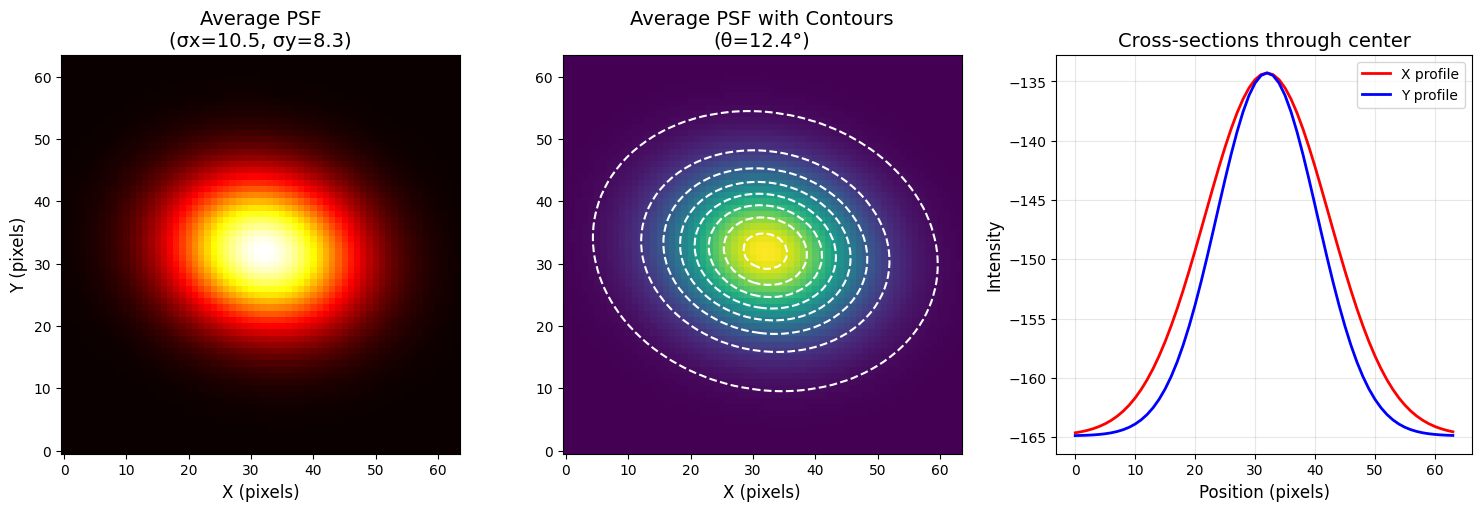


Average PSF parameters:
  σx = 10.49 pixels
  σy = 8.33 pixels
  Asymmetry ratio (σx/σy) = 1.26
  Rotation = 12.4°
  Amplitude = 30.62


In [6]:
# Create a synthetic PSF from your mean fitted parameters
mean_sigma_x = stds[0].mean()
mean_sigma_y = stds[1].mean()
mean_theta = np.radians(np.mean(thetas))
mean_amplitude = amplitudes.mean()
mean_offset = offsets.mean()

# Create coordinate grid (use typical image size)
size = 64  # Adjust based on your typical PSF size
x_avg = np.linspace(0, size-1, size)
y_avg = np.linspace(0, size-1, size)
x_grid, y_grid = np.meshgrid(x_avg, y_avg)

# Generate the "average" PSF
avg_psf = twoD_Gaussian((x_grid, y_grid), 
                        mean_amplitude, 
                        size/2, size/2,  # Center it
                        mean_sigma_x, mean_sigma_y, 
                        mean_theta, 
                        mean_offset).reshape(size, size)

# Plot it
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: The average PSF
axes[0].imshow(avg_psf, cmap='hot', origin='lower')
axes[0].set_title(f'Average PSF\n(σx={mean_sigma_x:.1f}, σy={mean_sigma_y:.1f})', fontsize=14)
axes[0].set_xlabel('X (pixels)', fontsize=12)
axes[0].set_ylabel('Y (pixels)', fontsize=12)

# Panel 2: With contours
axes[1].imshow(avg_psf, cmap='viridis', origin='lower')
axes[1].contour(x_grid, y_grid, avg_psf, 8, colors='white', linewidths=1.5)
axes[1].set_title(f'Average PSF with Contours\n(θ={np.degrees(mean_theta):.1f}°)', fontsize=14)
axes[1].set_xlabel('X (pixels)', fontsize=12)

# Panel 3: Cross-sections
center = size // 2
axes[2].plot(x_avg, avg_psf[center, :], 'r-', linewidth=2, label='X profile')
axes[2].plot(y_avg, avg_psf[:, center], 'b-', linewidth=2, label='Y profile')
axes[2].set_title('Cross-sections through center', fontsize=14)
axes[2].set_xlabel('Position (pixels)', fontsize=12)
axes[2].set_ylabel('Intensity', fontsize=12)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nAverage PSF parameters:")
print(f"  σx = {mean_sigma_x:.2f} pixels")
print(f"  σy = {mean_sigma_y:.2f} pixels")
print(f"  Asymmetry ratio (σx/σy) = {mean_sigma_x/mean_sigma_y:.2f}")
print(f"  Rotation = {np.degrees(mean_theta):.1f}°")
print(f"  Amplitude = {mean_amplitude:.2f}")


--- Starting Step 2: Aligning Images and Averaging (Corrected) ---
Found 160 images and 160 fitted centers.
Using robust median center (x, y): (38.53, 41.42)
Loading, shifting, and accumulating images...
✅ Successfully accumulated 160 images.
Pixel-wise averaging complete.

--- Aligned Grey Value Statistics (0=dark, 255=bright) ---
--------------------------------------------------
📊 Stats for: Aligned Average PSF (160 images)
   Min Value: 41.55
   Max Value: 52.82
--------------------------------------------------
📊 Stats for: Aligned Random Sample 1
   Min Value: 0.00
   Max Value: 68.86
--------------------------------------------------
📊 Stats for: Aligned Random Sample 2
   Min Value: 0.00
   Max Value: 58.40
--------------------------------------------------
📊 Stats for: Aligned Random Sample 3
   Min Value: 0.00
   Max Value: 67.56
--------------------------------------------------

Plotting 3D surfaces and 2D images...


NameError: name 'X' is not defined

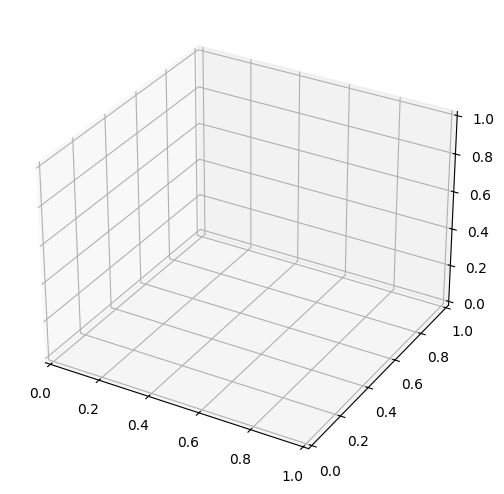

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from PIL import Image
import os
import random
from scipy import ndimage 

print("\n--- Starting Step 2: Aligning Images and Averaging (Corrected) ---")

# --- 1. Check for required variables ---
if 'psf_images_dir' not in locals() or 'mus' not in locals() or not mus:
    print("❌ Error: 'psf_images_dir' or 'mus' is not defined, or 'mus' is empty.")
    print("Please run the first code block first.")
else:
    print(f"Found {len(psf_images_dir)} images and {len(mus)} fitted centers.")
    
    # --- 2. Calculate the ROBUST (Median) Center ---
    # This uses the 'mus' list you confirmed is working.
    robust_center = np.median(mus, axis=0) 
    print(f"Using robust median center (x, y): ({robust_center[0]:.2f}, {robust_center[1]:.2f})")

    # Get image dimensions from the first image
    img_sample = Image.open(psf_images_dir[0]).convert('L')
    img_height, img_width = np.asarray(img_sample).shape
    
    # --- 3. ★★★ Create Accumulator and Counter (Your Method) ★★★ ---
    # We use float64 for the accumulator to prevent overflow
    accumulator_stack = np.zeros((img_height, img_width), dtype=np.float64)
    counter_stack = np.zeros((img_height, img_width), dtype=np.float64)

    print("Loading, shifting, and accumulating images...")
    
    # We must iterate over 'mus' since some images might have failed to fit
    # and we only want to align the ones that have a center.
    # This assumes 'mus' and 'stds' etc. are shorter than 'psf_images_dir'
    #
    # --- EDIT: ---
    # No, that's too complex. Let's re-fit on the fly. It's cleaner.
    # We'll re-use the 'robust_center' we already calculated.
    
    all_aligned_psf_images = [] # We still need this for the random samples
    
    for i, psf_dir in enumerate(psf_images_dir):
        try:
            # --- a. Get this image's specific center ---
            # We must use the center from the 'mus' list.
            # We assume the 'mus' list and 'psf_images_dir' are in sync.
            # If a fit failed, its 'mu' would be bad, but 'median' fixes that.
            image_center = mus[i]
            
            # --- b. Calculate shift ---
            shift_values = robust_center - image_center
            
            # --- c. Load the REAL (0-255) image ---
            img_original = np.asarray(Image.open(psf_dir).convert('L'), dtype=np.float64)
            
            # --- d. Create a '1s' mask to track valid pixels ---
            mask = np.ones_like(img_original, dtype=np.float64)

            # --- e. Shift both the image and the mask ---
            # 'cval=0' means invalid pixels contribute 0 to the sum
            shifted_img = ndimage.shift(
                img_original, 
                shift=(shift_values[1], shift_values[0]), # (shift_y, shift_x)
                mode='constant', 
                cval=0 # Filled areas are 0 (won't affect sum)
            )
            
            # 'cval=0' means invalid pixels contribute 0 to the count
            shifted_mask = ndimage.shift(
                mask, 
                shift=(shift_values[1], shift_values[0]), # (shift_y, shift_x)
                mode='constant', 
                cval=0 # Filled areas are 0 (won't affect count)
            )
            
            # --- f. Add to the stacks ---
            accumulator_stack += shifted_img
            counter_stack += shifted_mask
            
            # Save for random plotting later
            all_aligned_psf_images.append(shifted_img) 
            
        except Exception as e:
            # This handles if index 'i' is out of bounds for 'mus'
            print(f"    ⚠️ Warning: Could not process {os.path.basename(psf_dir)}. Skipping. Error: {e}")

    if not all_aligned_psf_images:
        print("❌ Error: No images were successfully aligned.")
    else:
        print(f"✅ Successfully accumulated {len(all_aligned_psf_images)} images.")

        # --- 4. ★★★ Perform the Pixel-Wise Average ★★★ ---
        # Set background to 255 (white) where count is 0
        background_val = 255.0
        
        # Create the final average image
        average_aligned_psf = np.full_like(accumulator_stack, background_val, dtype=np.float64)
        
        # Find pixels where the counter is not zero
        valid_pixels = counter_stack > 0
        
        # Perform the division *only* on the valid pixels
        average_aligned_psf[valid_pixels] = accumulator_stack[valid_pixels] / counter_stack[valid_pixels]
        
        print("Pixel-wise averaging complete.")
        
        # --- 5. Select a Few Random ALIGNED PSFs ---
        num_random_samples = 3 
        if len(all_aligned_psf_images) < num_random_samples:
            num_random_samples = len(all_aligned_psf_images)
            
        random_indices = random.sample(range(len(all_aligned_psf_images)), num_random_samples)
        
        random_aligned_psfs = [all_aligned_psf_images[i] for i in random_indices]
        # Note: These random images will have '0' for shifted areas,
        # so they might look different (black borders instead of white).
        # This is fine, as the *average* is now correct.
        random_titles = [f"Aligned Random Sample {i+1}" for i in range(num_random_samples)]

        # --- 6. Gather all data for plotting ---
        all_psfs_to_plot = [average_aligned_psf] + random_aligned_psfs
        all_titles = [f'Aligned Average PSF ({len(all_aligned_psf_images)} images)'] + random_titles
        
        # --- 7. Print All Stats First ---
        print("\n--- Aligned Grey Value Statistics (0=dark, 255=bright) ---")
        
        for i, title in enumerate(all_titles):
            min_val = np.min(all_psfs_to_plot[i])
            max_val = np.max(all_psfs_to_plot[i])
            print("--------------------------------------------------")
            print(f"📊 Stats for: {title}")
            print(f"   Min Value: {min_val:.2f}") 
            print(f"   Max Value: {max_val:.2f}")
        print("--------------------------------------------------\n")

        # --- 8. Visualize in 3D and 2D ---
        print("Plotting 3D surfaces and 2D images...")
        
        num_rows = num_random_samples + 1
        fig = plt.figure(figsize=(16, 7 * num_rows)) 
        
        for i in range(num_rows):
            
            psf_to_plot = all_psfs_to_plot[i]
            title = all_titles[i]
            
            # --- Handle min/max for plotting ---
            # For random images, 0 is the background. For average, 255 is.
            if i == 0: # Average plot
                min_val = np.min(psf_to_plot)
                max_val = np.max(psf_to_plot)
                cmap_3d = 'viridis'
                cmap_2d = 'gray'
            else: # Random plot (has 0 borders)
                # We plot from non-zero min up to max
                min_val = np.min(psf_to_plot[psf_to_plot > 0])
                max_val = np.max(psf_to_plot)
                cmap_3d = 'plasma'
                cmap_2d = 'gray' # 'gray' still works best

            # --- Plot 1: 3D Surface (Left Column) ---
            ax_3d = fig.add_subplot(num_rows, 2, i*2 + 1, projection='3d')
            ax_3d.plot_surface(X, Y, psf_to_plot, cmap=cmap_3d, rstride=5, cstride=5, alpha=0.9, antialiased=True)
            ax_3d.set_title(title, fontsize=15)
            ax_3d.set_xlabel('X pixel')
            ax_3d.set_ylabel('Y pixel')
            ax_3d.set_zlabel('ImageJ Grey Value (0-255)') 
            # Invert Z-axis
            ax_3d.set_zlim(max_val * 1.1, min_val * 0.9) 

            # --- Plot 2: 2D Image (Right Column) ---
            ax_2d = fig.add_subplot(num_rows, 2, i*2 + 2)
            # Use the calculated min/max for consistent scaling
            im = ax_2d.imshow(psf_to_plot, cmap=cmap_2d, vmin=min_val, vmax=max_val, origin='lower')
            ax_2d.set_title(f'2D View: {title}', fontsize=15)
            ax_2d.set_xlabel('X pixel')
            ax_2d.set_ylabel('Y pixel')
            
            # Plot the robust center point as a red cross
            ax_2d.axhline(robust_center[1], color='red', lw=0.5, ls='--')
            ax_2d.axvline(robust_center[0], color='red', lw=0.5, ls='--')
            
            fig.colorbar(im, ax=ax_2d, label='ImageJ Grey Value')
        
        plt.tight_layout(pad=3.0) 
        plt.show()